In [ ]:
import os
from google.colab import drive


drive.mount('/content/drive')

provided_zip_path = '/content/drive/MyDrive/chessboard_dataset.zip'
custom_zip_path = '/content/drive/MyDrive/custom_dataset.zip'

provided_dir = '/content/dataset_provided'
custom_dir = '/content/dataset_custom'

os.makedirs(provided_dir, exist_ok=True)
os.makedirs(custom_dir, exist_ok=True)

!unzip -q -o "{provided_zip_path}" -d "{provided_dir}"
!unzip -q -o "{custom_zip_path}" -d "{custom_dir}"

Mounted at /content/drive
Unzipping datasets...
Done! Data is ready in local Colab storage.


starting calibration...

found corners in 25 out of 25 images

intrinsic parameters
focal length  is  fx: 956.27   fy: 957.18
principal point  is  cx: 368.82   cy: 651.78
skew: 0.0000

extrinsics for first 2 images

image 1:
  rotation matrix:
[[-0.99702231 -0.01392467 -0.07584604]
 [ 0.02515001 -0.98849832 -0.14912598]
 [-0.07289715 -0.15058946  0.98590508]]
  translation: [ 3.11415752  1.14399249 15.91422526]

image 2:
  rotation matrix:
[[ 0.99829976  0.05381096 -0.02240482]
 [-0.05065117  0.99106235  0.12340941]
 [ 0.02884535 -0.12206475  0.99210289]]
  translation: [-4.36730418 -1.46559219 15.80907057]

distortion coefficients (k1, k2, p1, p2, k3) 
[ 0.19697178 -0.70161729  0.00382784  0.00678867  0.09781428]


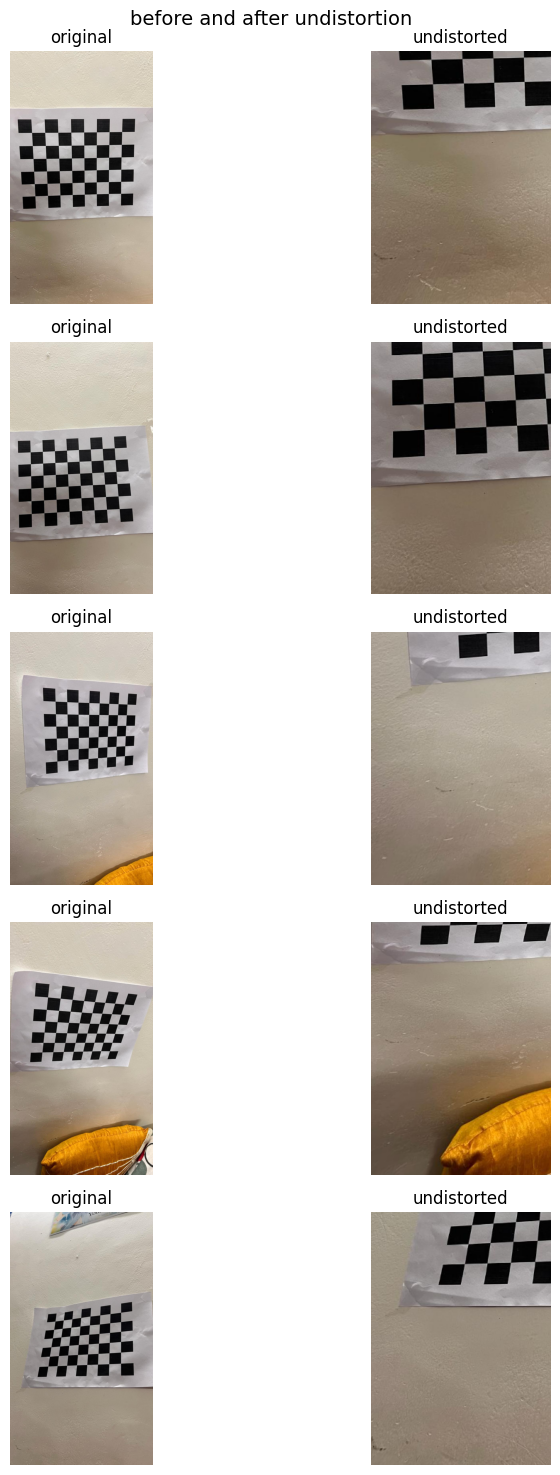


--- reprojection error ---
mean: 0.0696 px   std: 0.0230 px


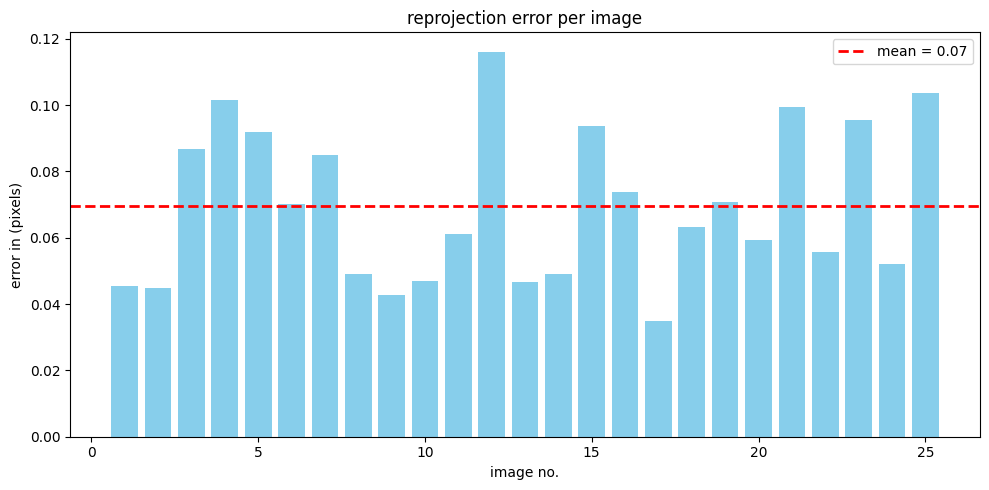


showing detected (green) vs reprojected (blue cross) corners for 3 images


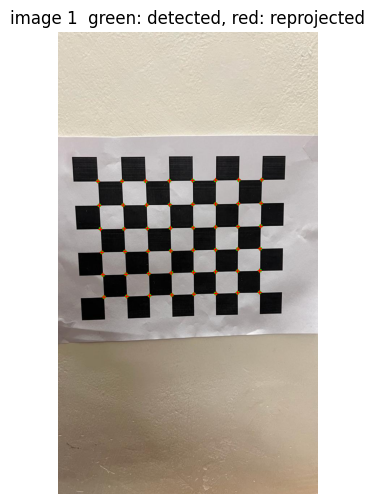

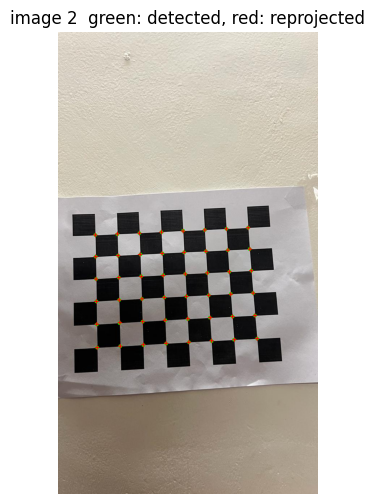

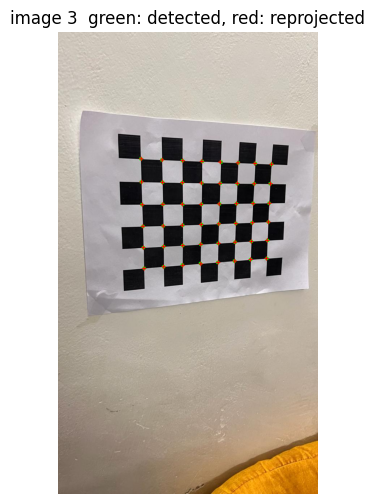


--- board plane normals (z-axis of each rotation matrix) ---
image 1: [-0.07584604 -0.14912598  0.98590508]
image 2: [-0.02240482  0.12340941  0.99210289]
image 3: [-0.39841567 -0.18760525  0.89781358]
image 4: [-0.34651262 -0.52832309  0.7751153 ]
image 5: [0.35825608 0.39821683 0.84443824]
image 6: [ 0.04560893 -0.32534175  0.94449594]
image 7: [-0.12722018 -0.50723759  0.85236439]
image 8: [0.07148576 0.21655395 0.97364992]
image 9: [-0.09455008  0.19676826  0.97588039]
image 10: [-0.14539983  0.07289927  0.98668363]
image 11: [-0.10742259 -0.0876322   0.99034387]
image 12: [-0.38489777 -0.30961831  0.86947697]
image 13: [-0.13485538 -0.10690162  0.98508176]
image 14: [-0.09738249 -0.27488779  0.95653194]
image 15: [-0.36033736  0.01772739  0.93265359]
image 16: [-0.16480856 -0.36286266  0.91715256]
image 17: [ 0.03637119 -0.11185543  0.99305866]
image 18: [-0.22287402  0.06766865  0.97249582]
image 19: [-0.27088227 -0.09693217  0.95771966]
image 20: [-0.16571531  0.15925247  0.973

In [ ]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
import json
import os

class camera_calib:
    def __init__(self, img_dir, name, board_size=(8, 6)):
        self.img_dir = img_dir
        self.name = name
        self.board_size = board_size

        self.all_imgs = []
        self.good_imgs = []
        self.obj_pts = []
        self.img_pts = []
        self.mtx = None
        self.dist = None
        self.rvecs = None
        self.tvecs = None
        self.errors = []
        self.img_shape = None

    def load_img(self):
        if not os.path.exists(self.img_dir):
            print("couldn't find that folder :(")
            return False

        extensions = ('*.jpeg', '*.JPEG')
        for ext in extensions:
            self.all_imgs.extend(glob.glob(os.path.join(self.img_dir, '**', ext), recursive=True))

        self.all_imgs.sort()

        if len(self.all_imgs) == 0:
            print("no images found")
            return False

        return True

    def find_corners(self):
        if not self.load_img():
            return False

        w, h = self.board_size

        objp = np.zeros((w * h, 3), np.float32)
        objp[:, :2] = np.mgrid[0:w, 0:h].T.reshape(-1, 2)

        flags = cv2.CALIB_CB_EXHAUSTIVE | cv2.CALIB_CB_ACCURACY

        for path in self.all_imgs:
            img = cv2.imread(path)
            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            if self.img_shape is None:
                self.img_shape = gray.shape[::-1]

            ret, corners = cv2.findChessboardCornersSB(gray, self.board_size, flags)

            if not ret:
                ret, corners = cv2.findChessboardCornersSB(gray, (h, w), flags)

            if ret:
                self.good_imgs.append(path)
                self.obj_pts.append(objp)
                self.img_pts.append(corners)

        print(f"found corners in {len(self.good_imgs)} out of {len(self.all_imgs)} images")

        if len(self.good_imgs) == 0:
            print("no usable images ")
            return False

        return True

    def run_calibration(self):
        ret, self.mtx, self.dist, self.rvecs, self.tvecs = cv2.calibrateCamera(self.obj_pts, self.img_pts, self.img_shape, None, None)

        if not ret:
            print("calibration failed")
            return False

        return True

    def show_params(self):
        print("\nintrinsic parameters")
        print(f"focal length  is  fx: {self.mtx[0,0]:.2f}   fy: {self.mtx[1,1]:.2f}")
        print(f"principal point  is  cx: {self.mtx[0,2]:.2f}   cy: {self.mtx[1,2]:.2f}")
        print(f"skew: {self.mtx[0,1]:.4f}")

        print("\nextrinsics for first 2 images")
        for i in range(min(2, len(self.rvecs))):
            R, _ = cv2.Rodrigues(self.rvecs[i])
            print(f"\nimage {i+1}:")
            print(f"rotation matrix:\n{R}")
            print(f"translation: {self.tvecs[i].ravel()}")

        print("\ndistortion coefficients for (k1, k2, p1, p2, k3) ")
        print(self.dist.ravel())

    def plot_undistorted(self):
        n = min(5, len(self.good_imgs))
        fig, axes = plt.subplots(n, 2, figsize=(10, 3 * n))

        fig.suptitle("before and after undistortion", fontsize=14)

        for i in range(n):
            img = cv2.imread(self.good_imgs[i])
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            h, w = img.shape[:2]
            new_mtx, roi = cv2.getOptimalNewCameraMatrix(self.mtx, self.dist, (w, h), 1, (w, h))
            undist = cv2.undistort(img_rgb, self.mtx, self.dist, None, new_mtx)

            x, y, w_roi, h_roi = roi
            undist = undist[y:y + h_roi, x:x + w_roi]

            axes[i, 0].imshow(img_rgb)
            axes[i, 0].set_title("original")
            axes[i, 0].axis('off')

            axes[i, 1].imshow(undist)
            axes[i, 1].set_title("undistorted")
            axes[i, 1].axis('off')

        plt.tight_layout()
        plt.show()

    def calc_errors(self):
        for i in range(len(self.obj_pts)):
            proj_pts, _ = cv2.projectPoints(self.obj_pts[i], self.rvecs[i], self.tvecs[i], self.mtx, self.dist)
            err = cv2.norm(self.img_pts[i], proj_pts, cv2.NORM_L2) / len(proj_pts)
            self.errors.append(err)

        mean_e = float(np.mean(self.errors))
        std_e = float(np.std(self.errors))

        print(f"\nreprojection error")
        print(f"mean: {mean_e:.4f} px   std: {std_e:.4f} px")

        plt.figure(figsize=(10, 5))
        plt.bar(range(1, len(self.errors) + 1), self.errors, color='skyblue')

        plt.axhline(mean_e, color='r', linestyle='dashed', linewidth=2, label=f'mean = {mean_e:.2f}')

        plt.title("reprojection error per image")
        plt.xlabel("image no.")
        plt.ylabel("error in (pixels)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def draw_corners(self):
        n = min(3, len(self.good_imgs))
        print(f"\nshowing detected (green) vs reprojected (blue cross) corners for {n} images")

        for i in range(n):
            img = cv2.imread(self.good_imgs[i])
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            proj_pts, _ = cv2.projectPoints(self.obj_pts[i], self.rvecs[i], self.tvecs[i], self.mtx, self.dist)

            for pt in self.img_pts[i]:
                cv2.circle(img_rgb, (int(pt[0][0]), int(pt[0][1])), 5, (0, 255, 0), -1)

            for pt in proj_pts:
                cv2.drawMarker(img_rgb, (int(pt[0][0]), int(pt[0][1])),(255, 0, 0), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)

            plt.figure(figsize=(8, 6))
            plt.imshow(img_rgb)
            plt.title(f"image {i+1}  green: detected, red: reprojected")
            plt.axis('off')
            plt.show()

    def get_normals(self):
        print("\nboard plane normals")
        for i in range(len(self.rvecs)):
            R, _ = cv2.Rodrigues(self.rvecs[i])
            print(f"image {i+1}: {R[:, 2]}")

    def save_json(self):
        extrinsics = []
        for i in range(len(self.rvecs)):
            R, _ = cv2.Rodrigues(self.rvecs[i])
            ext_dict = {"image_id": i + 1,
                "rotation_matrix": R.tolist(),
                "translation_vector": self.tvecs[i].flatten().tolist()}
            extrinsics.append(ext_dict)

        mean_e = 0.0
        std_e = 0.0
        if len(self.errors) > 0:
            mean_e = float(np.mean(self.errors))
            std_e = float(np.std(self.errors))

        data ={
            "intrinsic_parameters":{
                "focal_length": [float(self.mtx[0, 0]), float(self.mtx[1, 1])],
                "skew": float(self.mtx[0, 1]),
                "principal_point": [float(self.mtx[0, 2]), float(self.mtx[1, 2])]
            },
            "extrinsic_parameters": extrinsics,"radial_distortion_coefficients": self.dist.flatten().tolist(),
            "reprojection_errors":{
                "mean_error": mean_e,
                "std_dev": std_e}
        }

        filename = f"{self.name}_calib.json"
        with open(filename, 'w') as f:
            json.dump(data, f, indent=4)
        print("saved json file")

    def run_all(self):
        print("starting calibration\n")

        if not self.find_corners():
            return
        if not self.run_calibration():
            return

        self.show_params()
        self.plot_undistorted()
        self.calc_errors()
        self.draw_corners()
        self.get_normals()
        self.save_json()

calib = camera_calib('/content/dataset_provided', 'Provided_Dataset', (8, 6))
calib.run_all()

starting calibration...

found corners in 25 out of 25 images

intrinsic parameters
focal length  is  fx: 1492.48   fy: 1491.91
principal point  is  cx: 678.31   cy: 756.49
skew: 0.0000

extrinsics for first 2 images

image 1:
  rotation matrix:
[[-0.53371007  0.12894618  0.83577895]
 [-0.42352168 -0.89618999 -0.13218508]
 [ 0.73197196 -0.42451901  0.53291712]]
  translation: [-0.96929899  2.58713672 11.22663012]

image 2:
  rotation matrix:
[[ 0.98155159  0.17449347  0.07815697]
 [-0.18843663  0.81364647  0.54997369]
 [ 0.03237468 -0.55455518  0.83151695]]
  translation: [-2.49609319 -4.83198791 15.28216425]

distortion coefficients (k1, k2, p1, p2, k3) 
[-0.01552753 -0.48608113 -0.00623926 -0.01003004  0.85205581]


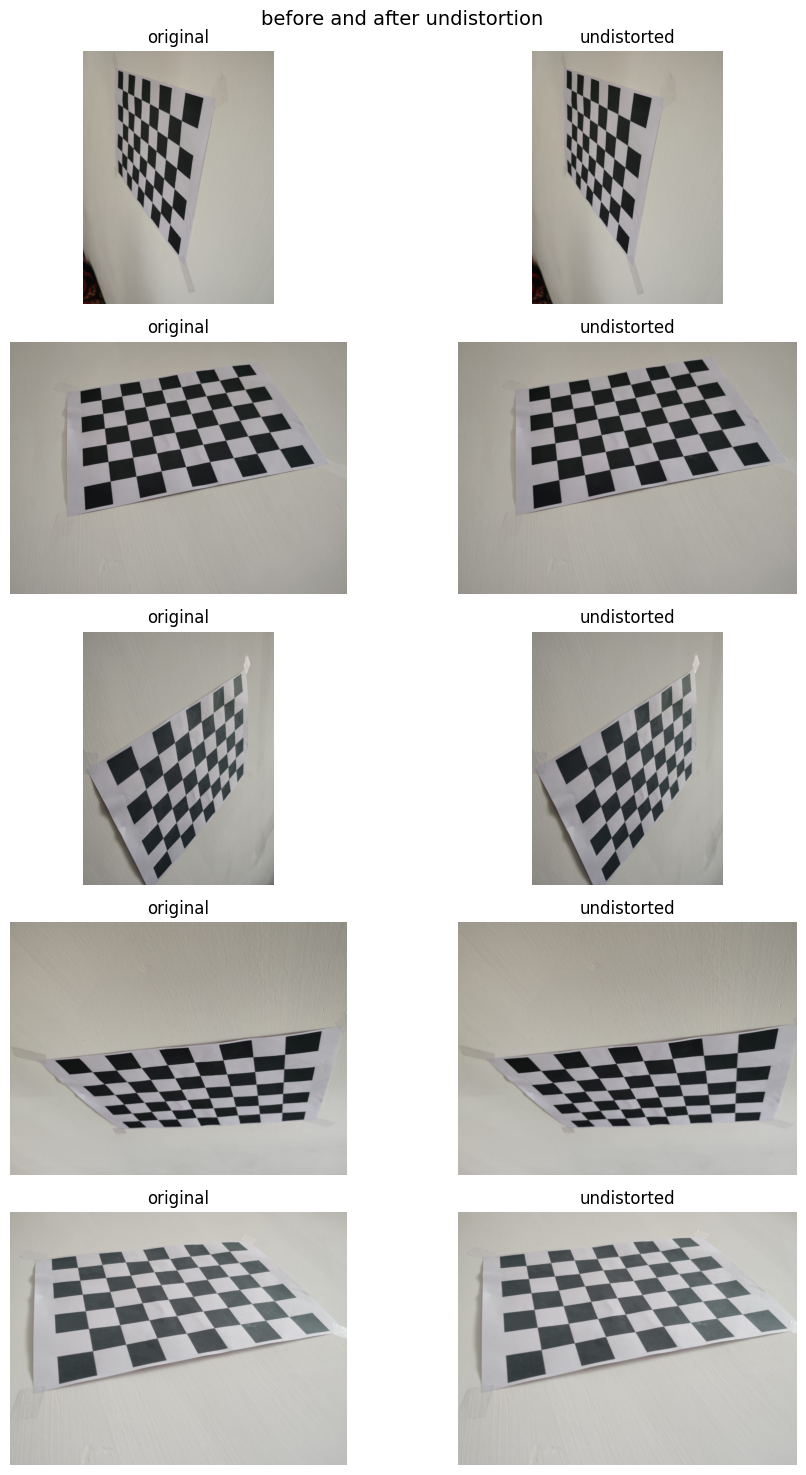


--- reprojection error ---
mean: 0.4399 px   std: 0.0693 px


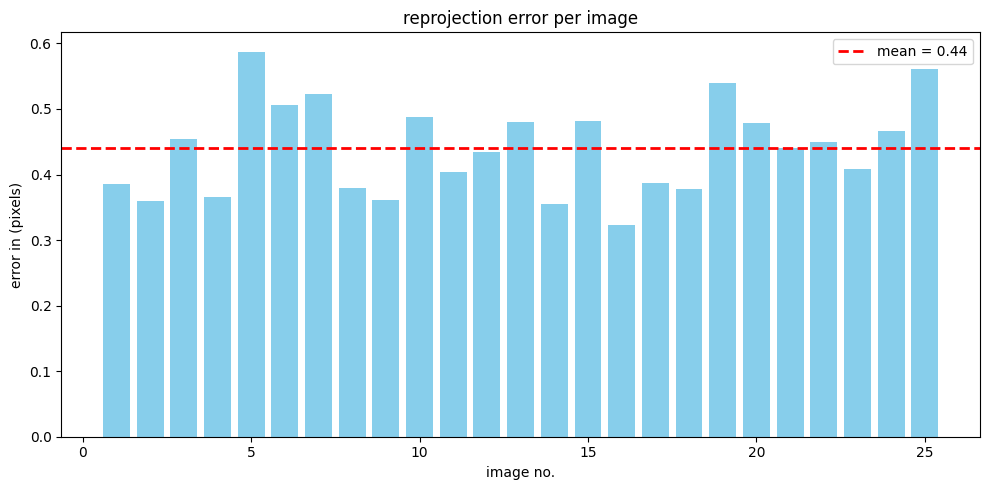


showing detected (green) vs reprojected (blue cross) corners for 3 images


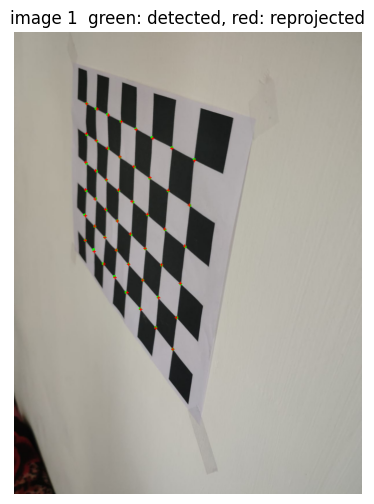

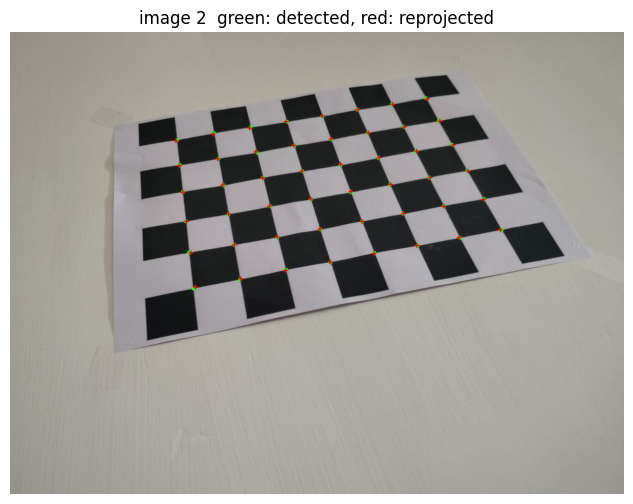

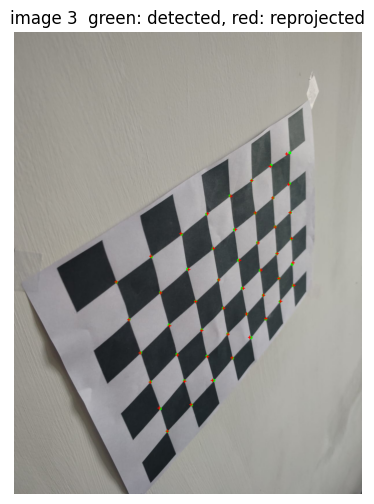


--- board plane normals (z-axis of each rotation matrix) ---
image 1: [ 0.83577895 -0.13218508  0.53291712]
image 2: [0.07815697 0.54997369 0.83151695]
image 3: [-0.78972844 -0.22378516  0.57118227]
image 4: [ 0.09200915 -0.87831715  0.46914103]
image 5: [-0.01947401  0.67649874  0.73618626]
image 6: [ 0.09891018 -0.79814585  0.59428948]
image 7: [-0.0155316  -0.91198849  0.40992166]
image 8: [ 0.01718017 -0.24659296  0.96896685]
image 9: [0.79058076 0.15948187 0.5912255 ]
image 10: [-0.09203391 -0.79386922  0.60108354]
image 11: [-0.83599945 -0.10684295  0.53822811]
image 12: [ 0.75202209 -0.18215445  0.63346865]
image 13: [-0.8137408  -0.16332737  0.55780828]
image 14: [ 0.35341195 -0.78593236  0.50735621]
image 15: [ 0.79513231 -0.1039936   0.59745288]
image 16: [-0.82658115 -0.11825818  0.55025322]
image 17: [ 0.81714343 -0.09572619  0.5684304 ]
image 18: [-0.85803057 -0.02788412  0.51284113]
image 19: [0.1131651  0.64862862 0.75264505]
image 20: [ 0.79083547 -0.20432656  0.576914

In [ ]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
import json
import os

class camera_calib:
    def __init__(self, img_dir, name, board_size=(8, 6)):
        self.img_dir = img_dir
        self.name = name
        self.board_size = board_size

        self.all_imgs = []
        self.good_imgs = []
        self.obj_pts = []
        self.img_pts = []
        self.mtx = None
        self.dist = None
        self.rvecs = None
        self.tvecs = None
        self.errors = []
        self.img_shape = None

    def load_img(self):
        if not os.path.exists(self.img_dir):
            print("couldn't find that folder :(")
            return False

        extensions = ('*.jpeg','*.JPEG')
        for ext in extensions:
            self.all_imgs.extend(glob.glob(os.path.join(self.img_dir, '**', ext), recursive=True))

        self.all_imgs.sort()

        if len(self.all_imgs) == 0:
            print("no images found")
            return False

        return True

    def find_corners(self):
        if not self.load_img():
            return False

        w, h = self.board_size

        objp = np.zeros((w * h, 3), np.float32)
        objp[:, :2] = np.mgrid[0:w, 0:h].T.reshape(-1, 2)

        flags = cv2.CALIB_CB_EXHAUSTIVE | cv2.CALIB_CB_ACCURACY

        for path in self.all_imgs:
            img = cv2.imread(path)
            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            if self.img_shape is None:
                self.img_shape = gray.shape[::-1]

            ret, corners = cv2.findChessboardCornersSB(gray, self.board_size, flags)

            if not ret:
                ret, corners = cv2.findChessboardCornersSB(gray, (h, w), flags)

            if ret:
                self.good_imgs.append(path)
                self.obj_pts.append(objp)
                self.img_pts.append(corners)

        print(f"found corners in {len(self.good_imgs)} out of {len(self.all_imgs)} images")

        if len(self.good_imgs) == 0:
            print("no usable images")
            return False

        return True

    def run_calibration(self):
        ret, self.mtx, self.dist, self.rvecs, self.tvecs = cv2.calibrateCamera(self.obj_pts, self.img_pts, self.img_shape, None, None)

        if not ret:
            print("calibration failed ")
            return False

        return True

    def show_params(self):
        print("\nintrinsic parameters")
        print(f"focal length  is  fx: {self.mtx[0,0]:.2f}   fy: {self.mtx[1,1]:.2f}")
        print(f"principal point  is  cx: {self.mtx[0,2]:.2f}   cy: {self.mtx[1,2]:.2f}")
        print(f"skew: {self.mtx[0,1]:.4f}")

        print("\nextrinsics for first 2 images")
        for i in range(min(2, len(self.rvecs))):
            R, _ = cv2.Rodrigues(self.rvecs[i])
            print(f"\nimage {i+1}:")
            print(f"  rotation matrix:\n{R}")
            print(f"  translation: {self.tvecs[i].ravel()}")

        print("\ndistortion coefficients for (k1, k2, p1, p2, k3) ")
        print(self.dist.ravel())

    def plot_undistorted(self):
        n = min(5, len(self.good_imgs))
        fig, axes = plt.subplots(n, 2, figsize=(10, 3 * n))

        fig.suptitle("before and after undistortion", fontsize=14)

        for i in range(n):
            img = cv2.imread(self.good_imgs[i])
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            h, w = img.shape[:2]
            new_mtx, roi = cv2.getOptimalNewCameraMatrix(self.mtx, self.dist, (w, h), 1, (w, h))
            undist = cv2.undistort(img_rgb, self.mtx, self.dist, None, new_mtx)

            x, y, w_roi, h_roi = roi
            undist = undist[y:y + h_roi, x:x + w_roi]

            axes[i, 0].imshow(img_rgb)
            axes[i, 0].set_title("original")
            axes[i, 0].axis('off')

            axes[i, 1].imshow(undist)
            axes[i, 1].set_title("undistorted")
            axes[i, 1].axis('off')

        plt.tight_layout()
        plt.show()

    def calc_errors(self):
        for i in range(len(self.obj_pts)):
            proj_pts, _ = cv2.projectPoints(self.obj_pts[i], self.rvecs[i], self.tvecs[i], self.mtx, self.dist)
            err = cv2.norm(self.img_pts[i], proj_pts, cv2.NORM_L2) / len(proj_pts)
            self.errors.append(err)

        mean_e = float(np.mean(self.errors))
        std_e = float(np.std(self.errors))

        print(f"\nreprojection error")
        print(f"mean: {mean_e:.4f} px   std: {std_e:.4f} px")

        plt.figure(figsize=(10, 5))
        plt.bar(range(1, len(self.errors) + 1), self.errors, color='skyblue')
        plt.axhline(mean_e, color='r', linestyle='dashed', linewidth=2, label=f'mean = {mean_e:.2f}')
        plt.title("reprojection error per image")
        plt.xlabel("image no")
        plt.ylabel("error in pixels")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def draw_corners(self):
        n = min(3, len(self.good_imgs))
        print(f"\nshowing detected (green) vs reprojected (blue cross) corners for {n} images")

        for i in range(n):
            img = cv2.imread(self.good_imgs[i])
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            proj_pts, _ = cv2.projectPoints(self.obj_pts[i], self.rvecs[i], self.tvecs[i], self.mtx, self.dist)

            for pt in self.img_pts[i]:
                cv2.circle(img_rgb, (int(pt[0][0]), int(pt[0][1])), 5, (0, 255, 0), -1)

            for pt in proj_pts:
                cv2.drawMarker(img_rgb, (int(pt[0][0]), int(pt[0][1])),(255, 0, 0), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)

            plt.figure(figsize=(8, 6))
            plt.imshow(img_rgb)
            plt.title(f"image {i+1}  green: detected, red: reprojected")
            plt.axis('off')
            plt.show()

    def get_normals(self):
        print("\n--- board plane normals (z-axis of each rotation matrix) ---")
        for i in range(len(self.rvecs)):
            R, _ = cv2.Rodrigues(self.rvecs[i])
            print(f"image {i+1}: {R[:, 2]}")

    def save_json(self):
        extrinsics = []
        for i in range(len(self.rvecs)):
            R, _ = cv2.Rodrigues(self.rvecs[i])
            extrinsics.append({
                "image_id": i + 1,
                "rotation_matrix": R.tolist(),
                "translation_vector": self.tvecs[i].flatten().tolist()
            })

        mean_e = float(np.mean(self.errors)) if len(self.errors) > 0 else 0.0
        std_e = float(np.std(self.errors)) if len(self.errors) > 0 else 0.0

        data = {"intrinsic_parameters": {
                "focal_length": [float(self.mtx[0, 0]), float(self.mtx[1, 1])],
                "skew": float(self.mtx[0, 1]),
                "principal_point": [float(self.mtx[0, 2]), float(self.mtx[1, 2])]
            },
            "extrinsic_parameters": extrinsics,
            "radial_distortion_coefficients": self.dist.flatten().tolist(),
            "reprojection_errors": {
                "mean_error": mean_e,
                "std_dev": std_e
            }
        }

        filename = f"{self.name}_calib.json"
        with open(filename, 'w') as f:
            json.dump(data, f, indent=4)
        

    def run_all(self):
        print("starting calibration\n")

        if not self.find_corners():
            return
        if not self.run_calibration():
            return

        self.show_params()
        self.plot_undistorted()
        self.calc_errors()
        self.draw_corners()
        self.get_normals()
        self.save_json()

calib = camera_calib('/content/dataset_custom','Custom_Dataset',(8, 6))
calib.run_all()